# Setup

In [46]:
# install libraries

In [47]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)
from functools import partial
from sklearn.base import clone
from ISLP.models import sklearn_sm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from ISLP.bart import BART
from scipy.stats import shapiro
from scipy import stats


In [48]:
# check working directory
os.getcwd()

'/Users/LauraSoerineVoldgaard/Desktop'

# Data wrangling and dataset creation

In [49]:
# load data
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3) # gini coefficient
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3) # GDP
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3) # inflation rate
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3) # unemployment rate
income = pd.read_csv('data/Real wage.csv') # median real earnings
satisfaction = pd.read_csv('data/satisfaction.csv') # satsifaction with personal life and with the US
election_results = pd.read_csv('data/election_results.csv') # electoral outcomes

### Inspect data

In [50]:
gini


,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.2,44.6,40.2,57.4,49.4,38.3,NaN,NaN,NaN,NaN
"Yemen, Rep.",YEM,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,54.1,NaN,NaN,NaN,NaN


In [51]:
gdp

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.485815,3.048518,0.951664,-23.466273,15.675519,11.038520,7.657640,6.181751,NaN,NaN
Africa Eastern and Southern,AFE,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-2.182395,5.075379,2.795642,1.790384,2.225029,1.922442,...,0.000238,-0.064991,-0.709407,-5.405934,1.844404,1.068005,-0.604582,0.253854,NaN,NaN
Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,NaN,NaN,NaN
Africa Western and Central,AFW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-0.251185,1.538542,4.740660,3.086962,1.823450,-3.703529,...,-0.355283,0.330202,0.792058,-6.003416,0.154018,2.064401,1.218110,2.107058,NaN,NaN
Angola,AGO,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.622865,-3.968525,-3.529000,-7.127615,-1.094341,0.991407,-1.808703,1.292933,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.038389,3.057529,5.236697,-5.406902,10.998140,5.339098,9.351075,10.365649,NaN,NaN
"Yemen, Rep.",YEM,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-7.888612,-2.186490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,0.971242,3.066160,4.168016,4.692929,2.909441,1.252170,...,0.498696,-0.137485,-1.380361,-7.678733,3.255620,0.625217,-0.523851,-0.713538,NaN,NaN


In [52]:
inflation

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,1.619450,NaN,NaN
"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288877,2.102351,1.246275,1.337971,2.534989,4.069019,3.489237,...,5.186187,4.509873,4.102851,3.232388,4.618745,7.039873,6.075244,4.361152,NaN,NaN


In [53]:
unemployment

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,NaN,NaN,11.710,5.679,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.240084,NaN,3.689777,NaN,NaN,3.337512,NaN,NaN,NaN,NaN
Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.431000,16.033,15.806,14.094000,12.885,13.937,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.344000,27.761,25.069000,25.459,20.392,12.093000,10.533,10.834,NaN,NaN
"Yemen, Rep.",YEM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27.035000,26.906,28.468000,29.217,34.007,33.268000,32.098,32.279,NaN,NaN


In [54]:
income

,observation_date,LES1252881600Q
0,1979-01-01,335.0
1,1979-04-01,335.0
2,1979-07-01,330.0
3,1979-10-01,326.0
4,1980-01-01,321.0
...,...,...
184,2025-01-01,373.0
185,2025-04-01,376.0
186,2025-07-01,376.0
187,2025-10-01,NaN


In [55]:
satisfaction

,"In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>",Personal life,United States
0,1/2/2025,81,20
1,1/2/2024,78,20
2,1/2/2023,83,23
3,1/3/2022,85,17
4,1/4/2021,82,11
...,...,...,...
58,6/5/1981,81,33
59,1/9/1981,81,17
60,11/2/1979,79,19
61,7/13/1979,73,12


In [56]:
election_results

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis


### Filter, re-format and rename

#### Gini, GDP, inflation and unemployment

In [57]:
# filter rows - keep the US only
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [58]:
# filter columns - drop metadata
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [59]:
# convert from wide to long format
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [60]:
# convert "year" column from string to integer
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

#### Income and satisfaction

In [61]:
# rename column
income = income.rename(columns={"LES1252881600Q": "median_real_wage"})

In [62]:
# extract year
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,median_real_wage,year
0,1979-01-01,335.0,1979
1,1979-04-01,335.0,1979
2,1979-07-01,330.0,1979
3,1979-10-01,326.0,1979
4,1980-01-01,321.0,1980


In [63]:
# add column only with year
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

Det er kompliceret - man kunne(burde) optælle hvor mange målinger der er hvert år og bruge det til at kvantificere hvor sikker man er på mållingen fra det konkrete år - der er ogs noget der hedder missingforest - man kunne også bruge noget timeseries interpolation for at få seasonality i især us med

In [64]:
# take the mean of multiple observations during a single year
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean() # distribute satisfaction to satsfaction with personal life
yearly_us = satisfaction.groupby('year')['United States'].mean() # distribute satisfaction to satisfaction with the US

In [65]:
# convert each series into a dataframe
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [66]:
# move year index back into a regular column
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [67]:
# make income and satisfaction integer
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [68]:
# check that it worked
yearly_pers

,year,pers
0,1979,76.333333
1,1981,81.000000
2,1982,75.500000
3,1983,77.000000
4,1984,79.000000
5,1985,82.000000
6,1986,84.000000
7,1987,83.000000
8,1988,86.500000
9,1990,84.000000


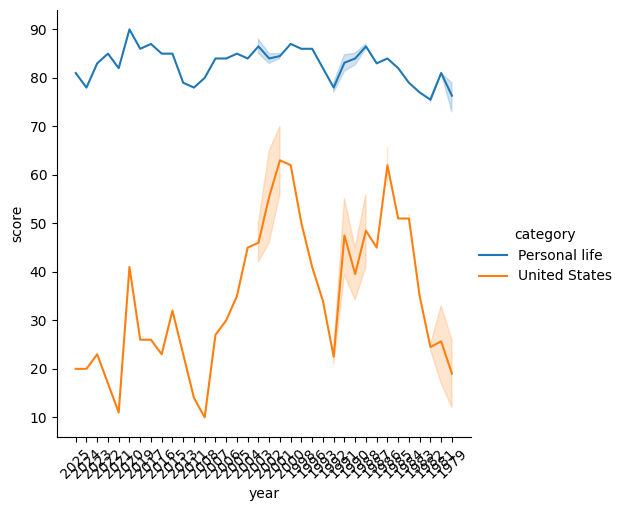

In [69]:
# Melt wide → long format
satisfaction_long = satisfaction.melt(
    id_vars="year",
    value_vars=["Personal life", "United States"],
    var_name="category",
    value_name="score"
)

# Plot with hue to separate the two lines
g = sns.relplot(
    data=satisfaction_long,
    x="year",
    y="score",
    hue="category",
    kind="line"
)

g.tick_params(axis='x', rotation=45)

### Weighted average

In [70]:
# Create function and define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 1:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4] # define weights



In [71]:
# Apply weight function
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights) # gini
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights) # GDP
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights) # unemployment
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights) # inflation
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights) # income
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights) # satisfaction with personal life
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights) # satisfaction with the US


In [72]:
# check
inflation_weighted

,year,inflation
0,2024,4.485057
1,2020,1.738624
2,2016,1.011149
3,2012,2.067241
4,2008,3.375905
5,2004,2.351747
6,2000,2.551376
7,1996,2.830762
8,1992,4.044309
9,1988,3.464639


In [73]:
pers_weighted

,year,pers
0,2024,81.300000
1,2020,88.000000
2,2016,83.666667
3,2012,78.000000
4,2008,82.500000
5,2004,84.800000
6,2000,86.571429
7,1996,84.285714
8,1992,81.041667
9,1988,84.500000


### Merge data

In [74]:
# merge to single dataframe
prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year') # gini
prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year']) # GDP
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year']) # unemployment
prediction_data = pd.merge(prediction_data, inflation_weighted, how = 'left', on=['year']) # inflation
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year']) # income
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year']) # satisaction with personal life
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year']) # satisfaction with the US


In [75]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


Sjovt at se at de her værdier er væsentligt anderledes end lineær interpolation

### Standardization and reformatting

In [76]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [77]:
# drop missing values
prediction_data = prediction_data.dropna()

In [78]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [79]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [80]:
# make ordinal
enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #maybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

/var/folders/62/r0msxcz92vb9fm2tjnbplzb80000gn/T/ipykernel_35149/4048338162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])
/var/folders/62/r0msxcz92vb9fm2tjnbplzb80000gn/T/ipykernel_35149/4048338162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(predi

In [81]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,0.0,0.0,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,4.485057,366.700,81.300000,19.400000
1,2020,0.0,0.0,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.738624,365.250,88.000000,32.666667
2,2016,2.0,0.0,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.011149,341.275,83.666667,26.000000
3,2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000
4,2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
5,2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
6,2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
7,1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
8,1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
9,1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000


In [82]:
# make years index
prediction_data = prediction_data.set_index('year')

In [83]:
# make years in ascending order
prediction_data = prediction_data.sort_index()

In [84]:
# check
prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,34.83,1.368685,6.5100,10.972383,323.500,76.333333,19.000000
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,37.00,3.221044,8.5800,4.943702,313.250,77.900000,38.366667
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,3.464639,326.175,84.500000,50.400000
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,4.044309,314.750,81.041667,34.623457
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.830762,314.175,84.285714,38.000000
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,2.551376,328.275,86.571429,56.857143
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.351747,337.350,84.800000,49.200000
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.375905,334.450,82.500000,21.600000
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.067241,337.600,78.000000,14.000000


SÅ ER DATAEN FÆRDIG

# Exploratory analysis

In [85]:
# standardize
scaled_prediction_data = prediction_data.copy()

cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

sc = StandardScaler()
scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

scaled_prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,-2.291322,-0.393346,0.330846,2.968804,-0.587584,-1.756298,-1.081536
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,-1.238640,1.491179,1.807505,0.523495,-1.186116,-1.303363,0.378828
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,-0.986384,1.145824,0.095436,-0.076432,-0.431381,0.604745,1.286214
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,-0.637107,-0.944981,0.459251,0.158689,-1.098526,-0.395085,0.096567
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,0.279745,0.414211,-0.183346,-0.333541,-1.132102,0.542793,0.351179
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,0.260341,1.492255,-1.270867,-0.446863,-0.308755,1.203610,1.773121
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,0.498043,0.126423,-0.291206,-0.527835,0.221165,0.691477,1.195726
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,0.818214,-1.182503,-0.651312,-0.112423,0.051824,0.026530,-0.885480
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,0.687235,-0.928747,1.938978,-0.643234,0.235763,-1.274452,-1.458566


In [86]:
print(scaled_prediction_data.head())

      prospective conscutive term for incumbent party  \
year                                                    
1980                                              1.0   
1984                                              1.0   
1988                                              2.0   
1992                                              3.0   
1996                                              1.0   

      prospective 1st/2nd term for incumbent party candidate incumbent party  \
year                                                                           
1980                                                1.0           Democratic   
1984                                                1.0           Republican   
1988                                                0.0           Republican   
1992                                                1.0           Republican   
1996                                                1.0           Democratic   

      popular vote for incumbent party 

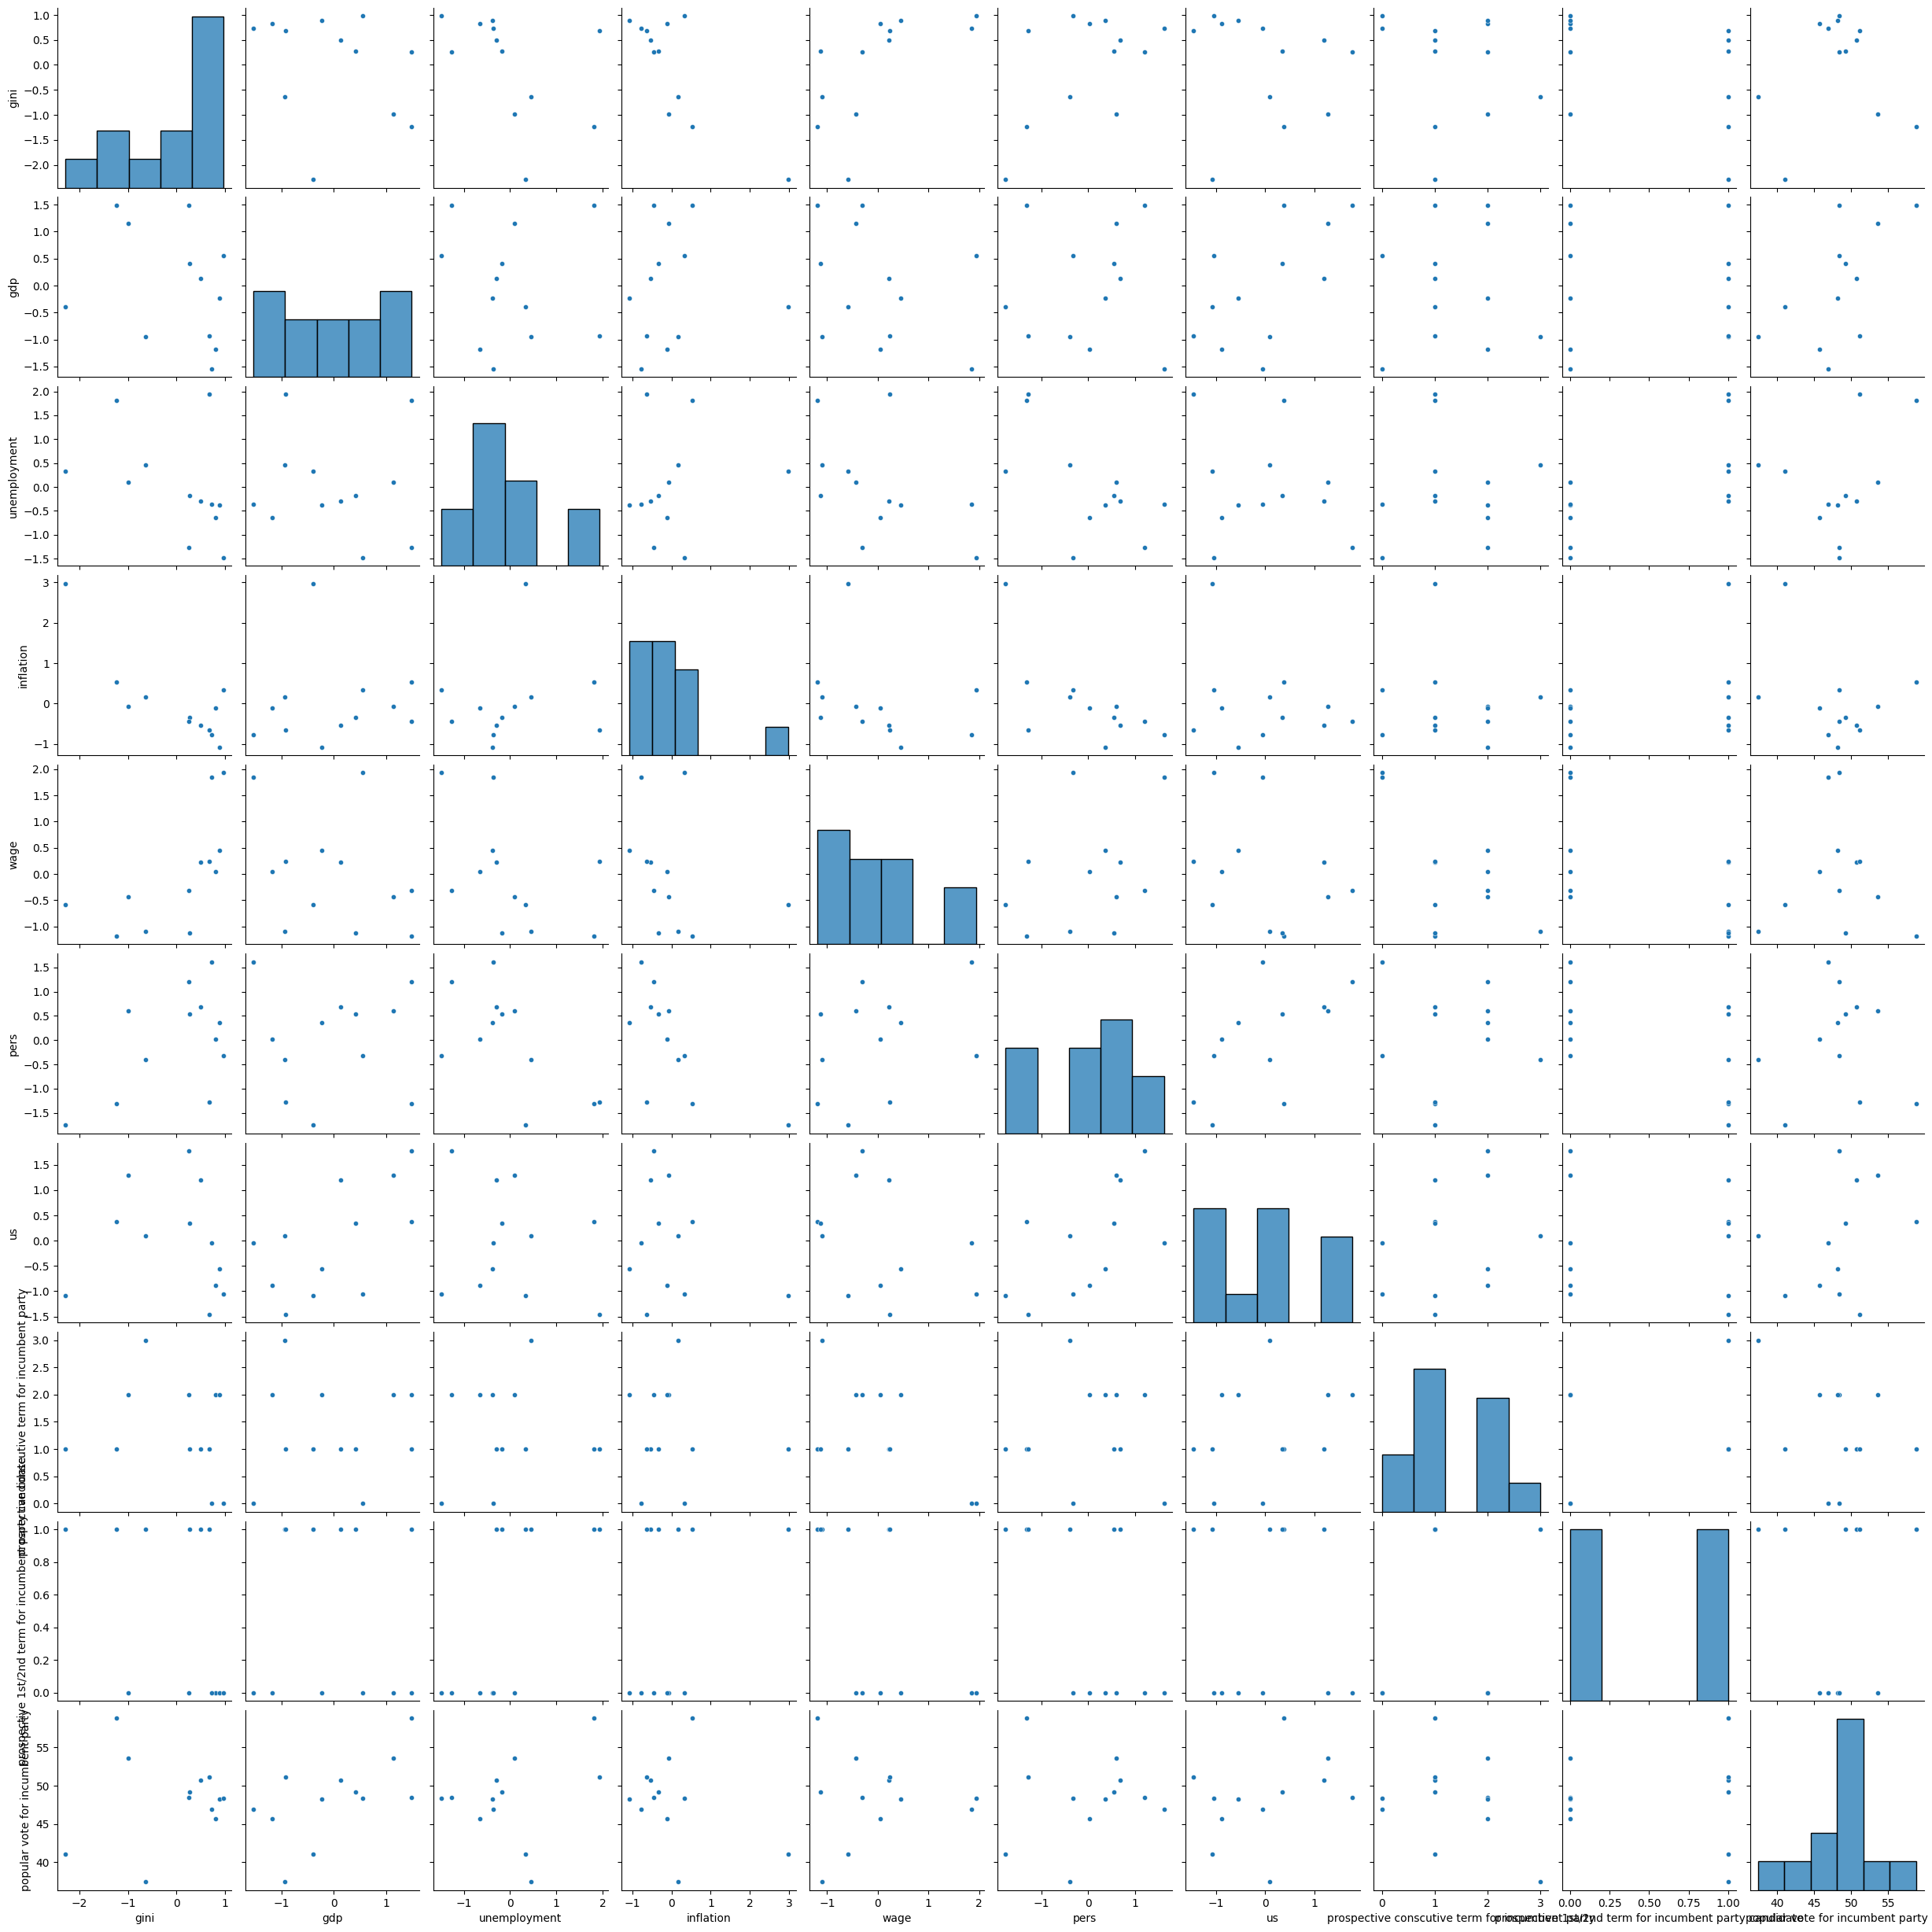

In [87]:
# plot colinearity
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(scaled_prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

In [88]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gini,42.379545
gdp,4.013833
unemployment,22.838278
inflation,53.000320
wage,3.168965
pers,22.538819
us,11.596372
prospective conscutive term for incumbent party,4.666984
prospective 1st/2nd term for incumbent party candidate,5.643797


In [89]:
# check normality to use pearsons
for col in cols:
    stat, p = shapiro(scaled_prediction_data[col])
    print(f"{col}: p = {p:.3f} {'✅ normal' if p > 0.05 else '❌ not normal'}")

gini: p = 0.033 ❌ not normal
gdp: p = 0.522 ✅ normal
unemployment: p = 0.266 ✅ normal
inflation: p = 0.004 ❌ not normal
wage: p = 0.114 ✅ normal
pers: p = 0.751 ✅ normal
us: p = 0.606 ✅ normal
prospective conscutive term for incumbent party: p = 0.160 ✅ normal
prospective 1st/2nd term for incumbent party candidate: p = 0.000 ❌ not normal
popular vote for incumbent party: p = 0.750 ✅ normal


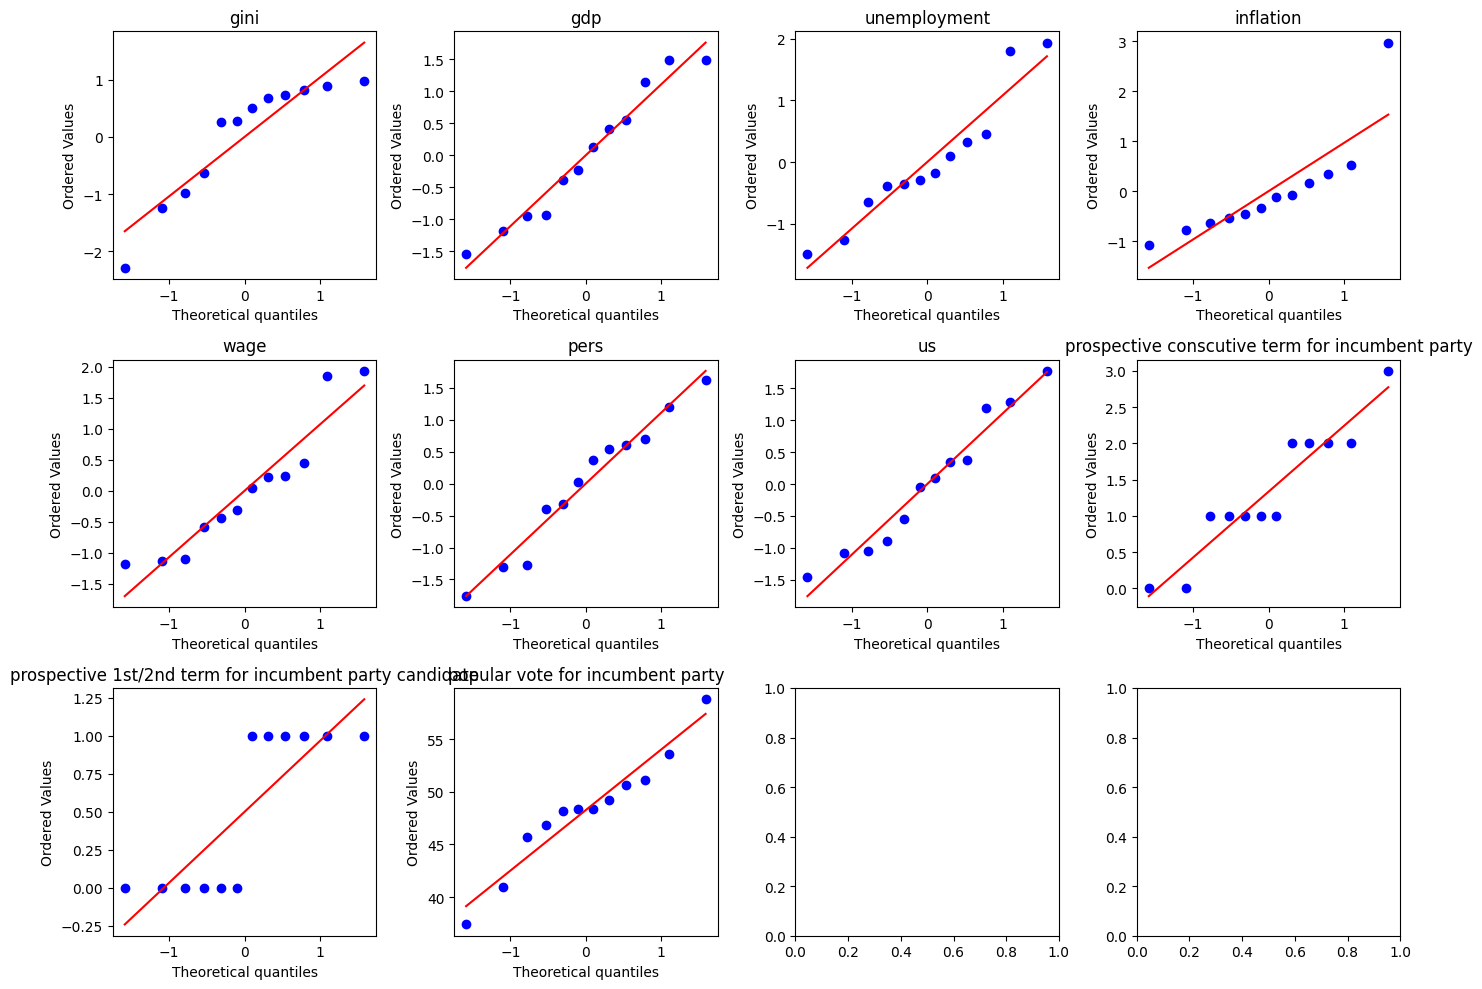

In [90]:
# check linearity to use pearsons

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(scaled_prediction_data[col], plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

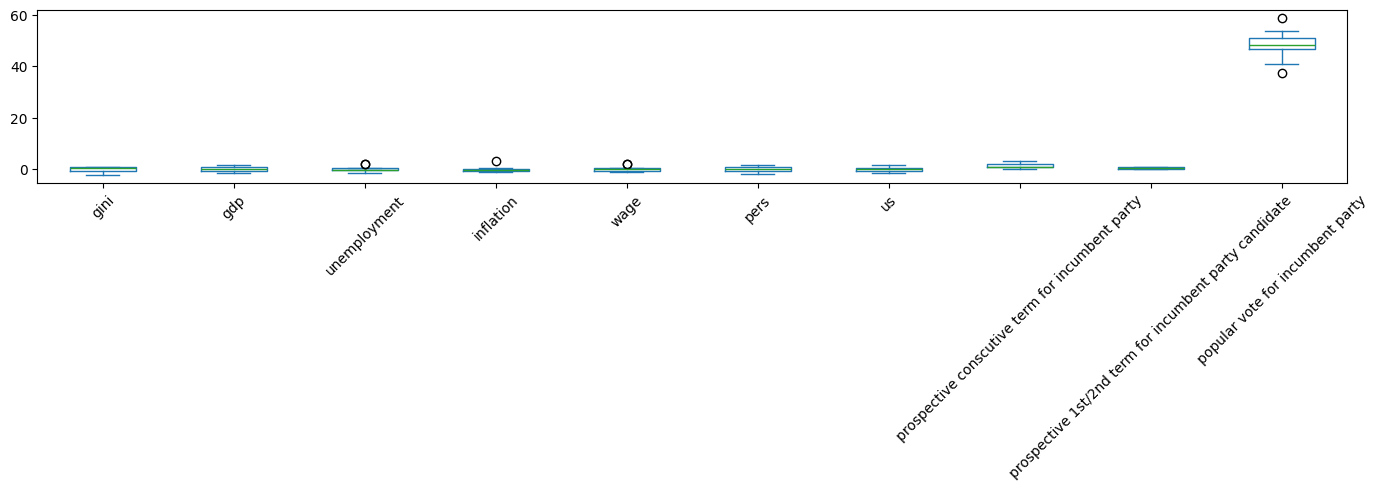

In [91]:
# check outliers
scaled_prediction_data[cols].plot(kind='box', figsize=(14, 5), rot=45)
plt.tight_layout()
plt.show()

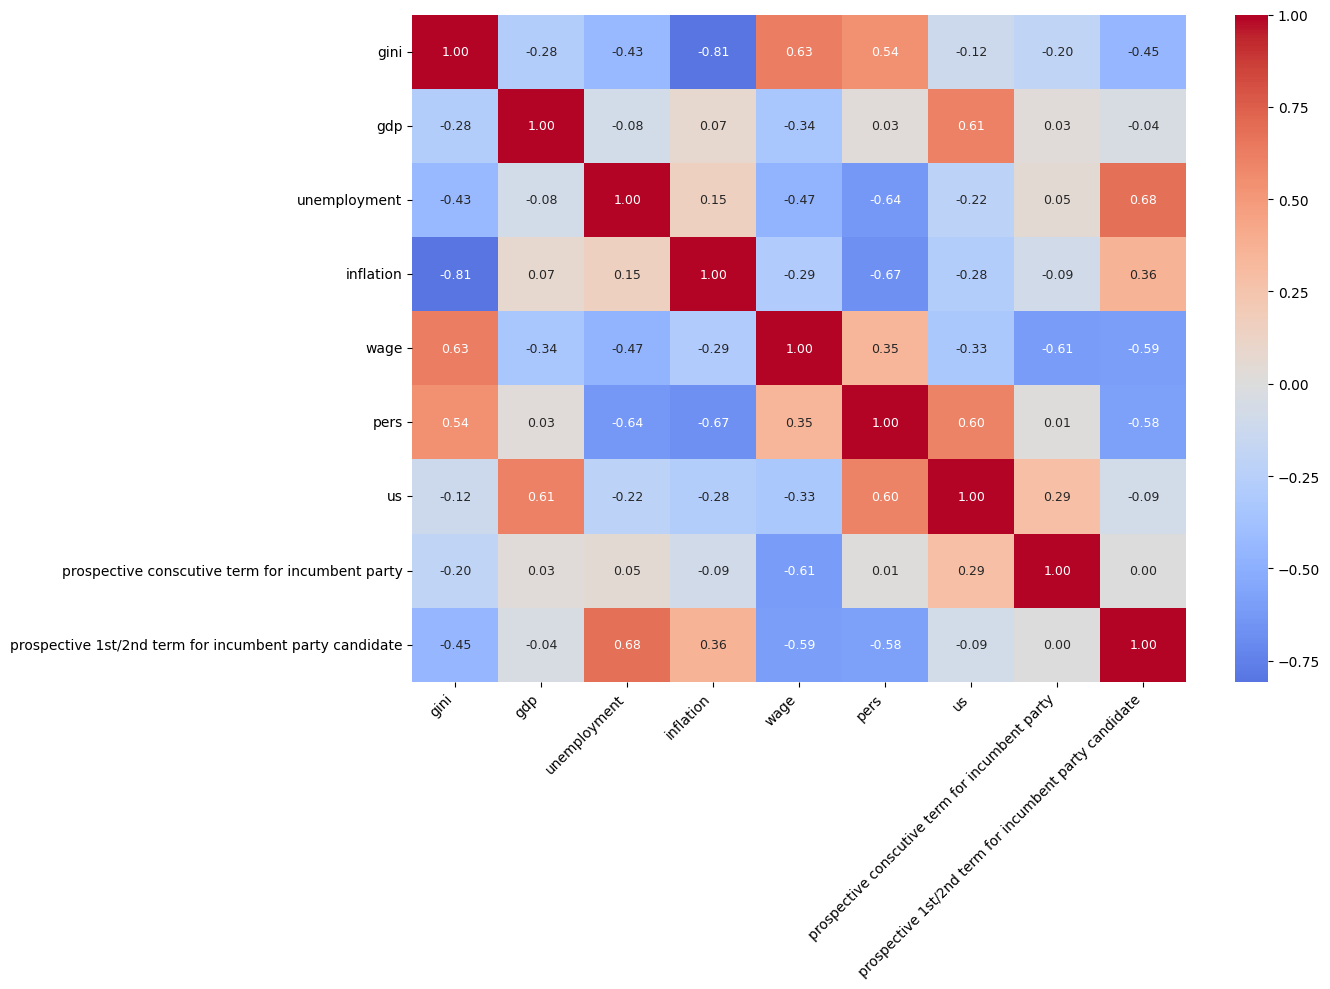

In [92]:
# correlation matrix (pearson)
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 
        'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

corr = scaled_prediction_data[cols].corr()

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

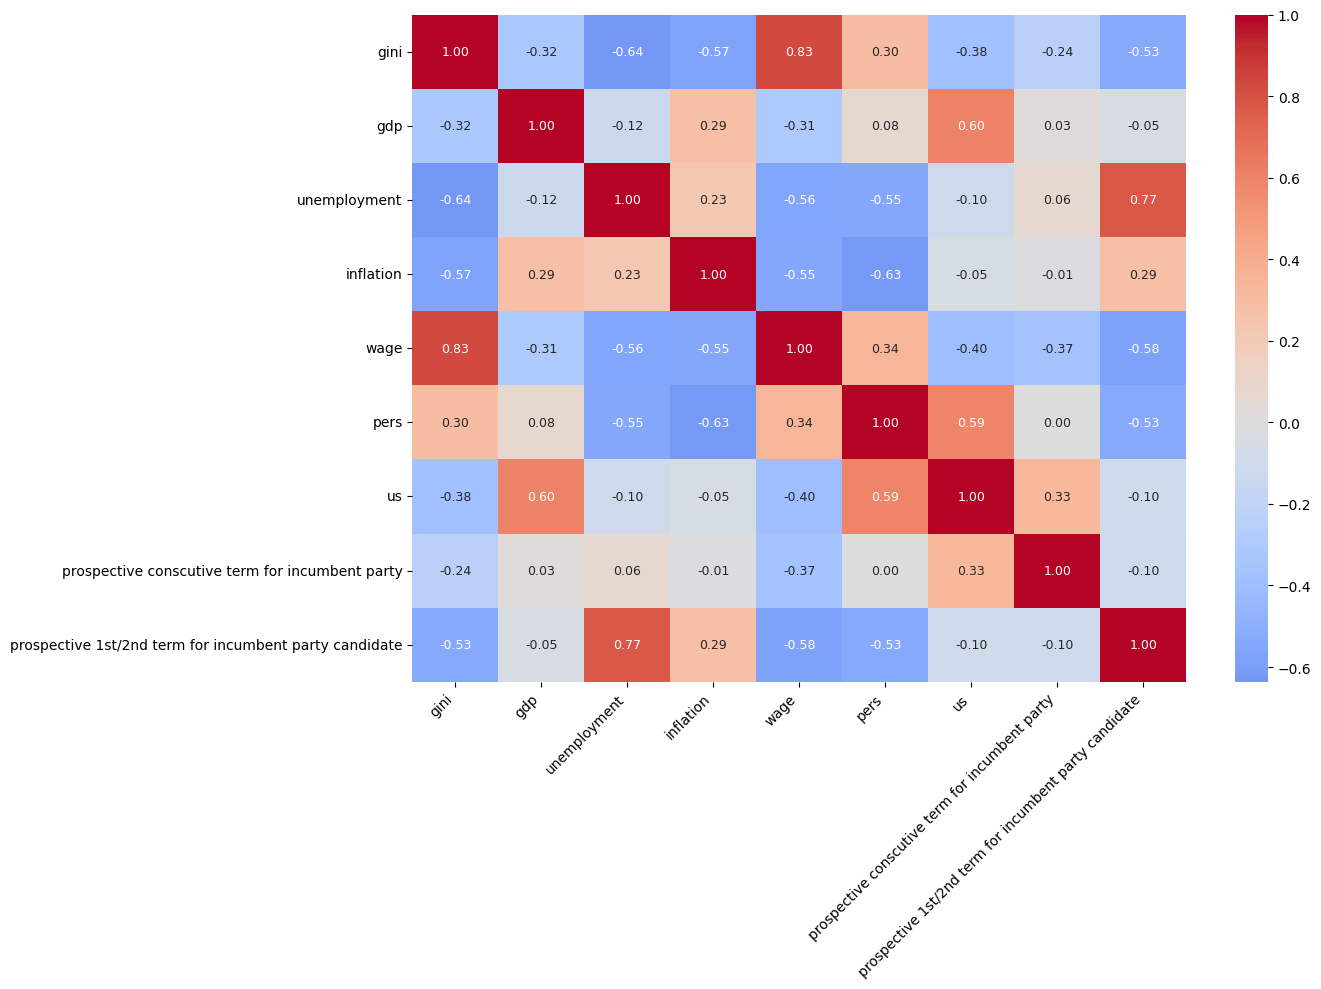

In [93]:
# spearman correlation matrix
corr_spearman = prediction_data[cols].corr(method='spearman')
corr_spearman

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

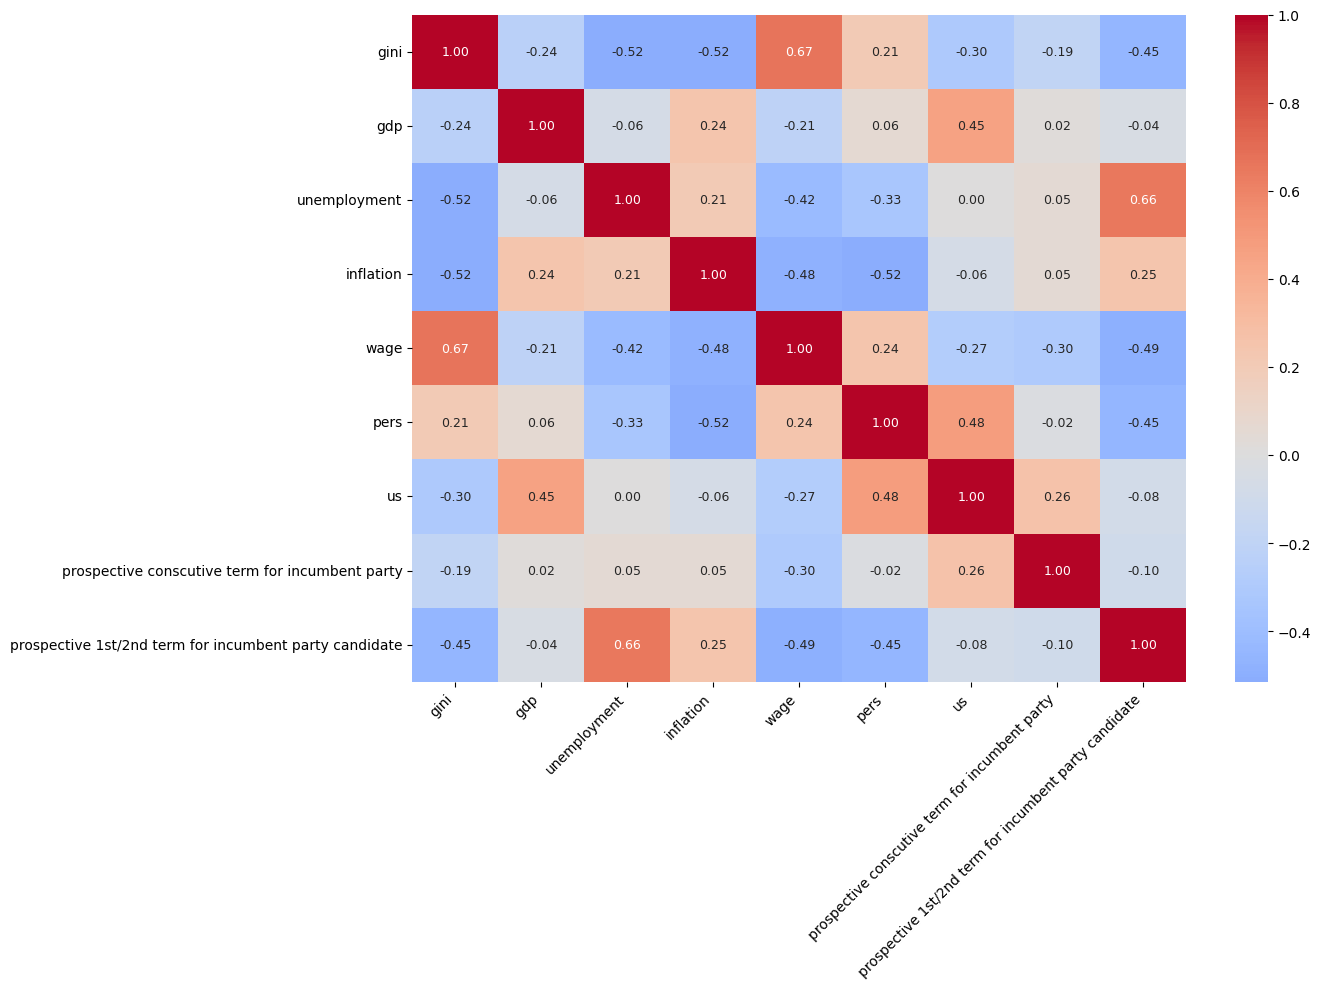

In [94]:
# kendall correlation matrix
corr_kendall = scaled_prediction_data[cols].corr(method='kendall')
corr_kendall

# Heatmap
plt.figure(figsize=(14, 10))  # much bigger

sns.heatmap(corr_kendall, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})  # smaller font so numbers fit

plt.xticks(rotation=45, ha='right')  # rotate x labels so they don't overlap
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

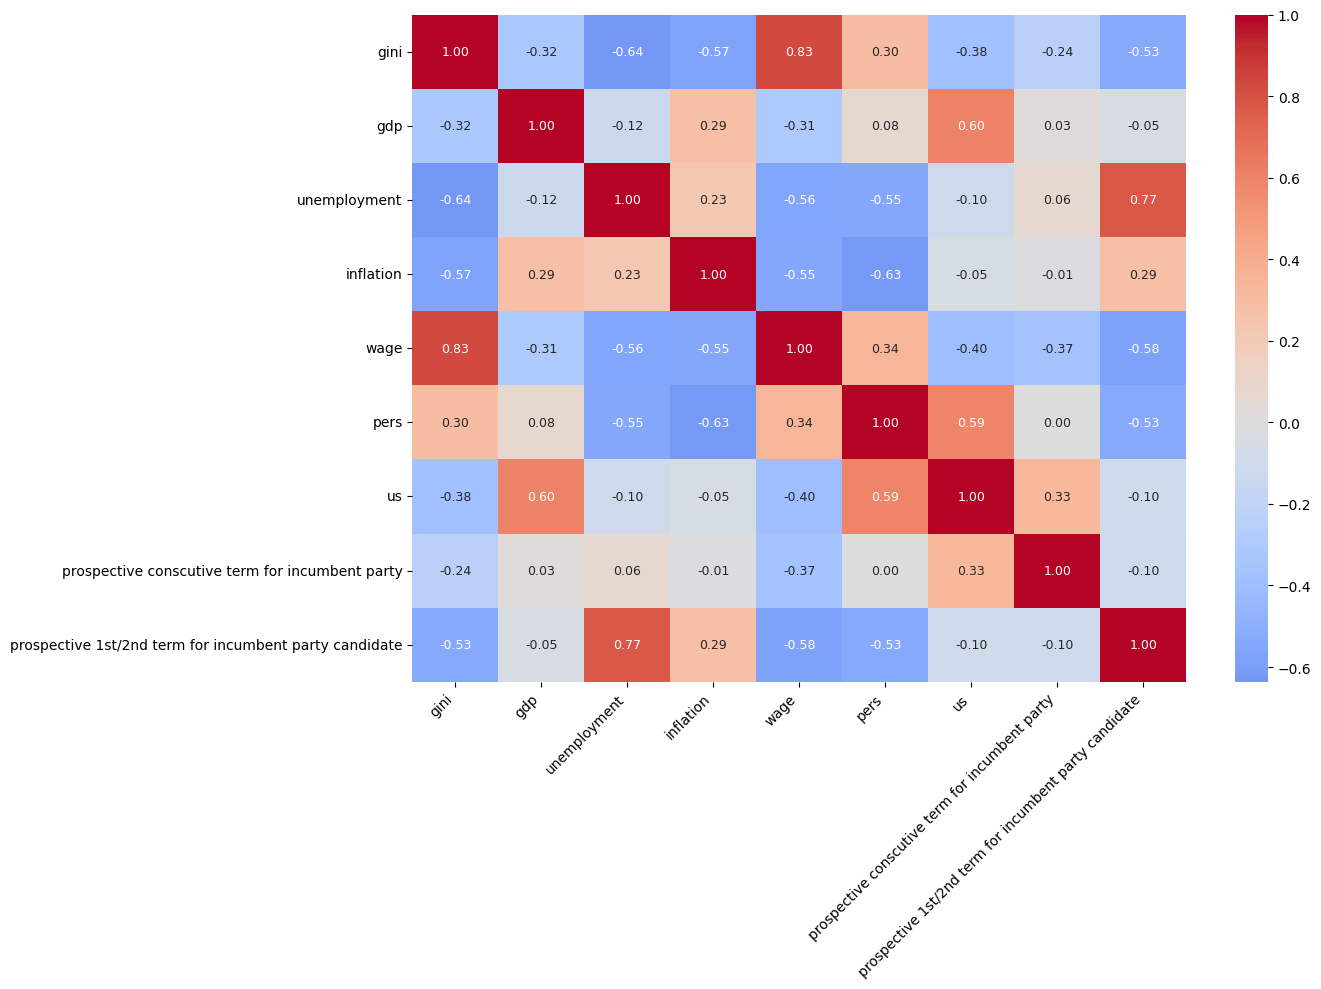

In [95]:
# save plot
plt.figure(figsize=(14, 10))

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 9})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_heatmap_spearman.jpg", dpi=150, bbox_inches='tight')  # add this line
plt.show()

problems from the book:
1. Non-linearity of the response-predictor relationships. 
2. Correlation of error terms. 
3. Non-constant variance of error terms. 
4. Outliers. 
5. High-leverage points. 
6. Collinearity. - decreases accuracy -indentifiability problems
and thus rreduces power of the test, increases p values

## linear regression: 


In [96]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

econ_cols = ['gini', 'gdp','unemployment', 'inflation', 'wage']

# Scale first — PCA is sensitive to scale
scaler = StandardScaler()
econ_scaled = scaler.fit_transform(prediction_data[econ_cols])

# Fit PCA
pca = PCA()
pca.fit(econ_scaled)

# Check how many components to keep
print(pd.Series(pca.explained_variance_ratio_, 
                index=[f'PC{i+1}' for i in range(len(econ_cols))]))


# Keep however many components make sense (e.g. 2)
pca = PCA(n_components=3)
econ_pca = pca.fit_transform(econ_scaled)

prediction_data['econ_PC1'] = econ_pca[:, 0]
prediction_data['econ_PC2'] = econ_pca[:, 1]
prediction_data['econ_PC3'] = econ_pca[:, 2]

# Check what each component represents
loadings = pd.DataFrame(pca.components_.T, 
                         index=econ_cols, 
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings)

PC1    0.502363
PC2    0.215500
PC3    0.190832
PC4    0.074008
PC5    0.017297
dtype: float64
                   PC1       PC2       PC3
gini          0.597454  0.005517 -0.232075
gdp          -0.223707  0.832381 -0.251917
unemployment -0.359798 -0.546687 -0.506378
inflation    -0.462596 -0.051187  0.670270
wage          0.499554 -0.074992  0.420713


In [97]:
import numpy as np
from scipy import stats

data = prediction_data['popular vote for incumbent party'].dropna()

n = len(data)
mean = data.mean()
se = data.std() / np.sqrt(n)          # standard error of the mean

# Using t-distribution (correct for unknown population std)
ci = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)

print(f"Mean:  {mean:.4f}")
print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Mean:  48.2750
95% CI: (44.7755, 51.7745)


In [98]:
# save as df
null_pred = pd.DataFrame({
    'actual': data.values,
    'null': mean,
    'null_lower': ci[0],
    'null_upper': ci[1]
})

null_pred

,actual,null,null_lower,null_upper
0,41.00,48.275,44.775494,51.774506
1,58.80,48.275,44.775494,51.774506
2,53.60,48.275,44.775494,51.774506
3,37.40,48.275,44.775494,51.774506
4,49.20,48.275,44.775494,51.774506
5,48.40,48.275,44.775494,51.774506
6,50.70,48.275,44.775494,51.774506
7,45.70,48.275,44.775494,51.774506
8,51.10,48.275,44.775494,51.774506
9,48.20,48.275,44.775494,51.774506


In [99]:
# save df
null_pred.to_csv('null_pred.csv', index=False)

In [100]:
data = prediction_data['popular vote for incumbent party'].dropna()

n = len(data)
mean = data.mean()
se_prediction = data.std() * np.sqrt(1 + 1/n)   # prediction SE, not standard error of mean

ci_prediction = stats.t.interval(0.95, df=n-1, loc=mean, scale=se_prediction)

print(f"Null model prediction: {mean:.4f}")
print(f"95% prediction interval: ({ci_prediction[0]:.4f}, {ci_prediction[1]:.4f})")

Null model prediction: 48.2750
95% prediction interval: (35.6574, 60.8926)


In [101]:
all_cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']
cv_df = pd.DataFrame()
pred_df = pd.DataFrame()
var_df = pd.DataFrame({'predictor': all_cols})

In [102]:
# Null model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = []

pipe = Pipeline([
    ('features', MS(cols)),
    ('scaler', StandardScaler()),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-3.541210286773116


{'fit_time': array([0.01027298, 0.00196099, 0.00177598, 0.00189066, 0.00199914,
        0.00187373, 0.00182223, 0.00164485]),
 'score_time': array([0.00070906, 0.00083995, 0.00052094, 0.00070024, 0.00059295,
        0.00058007, 0.00050592, 0.00061917]),
 'test_score': array([-2.25000000e+00, -1.60000000e-01, -6.93444444e+00, -7.52326531e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [103]:
# null model prdeicting last elections
cols = []
name = 'linear_null'

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS, MS(cols))
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions.values
}, index=Y_test.index)



print(results_df)
print(mse)

      actual  linear_null
year                     
2016   48.20    48.433333
2020   46.86    48.433333
2024   48.34    48.433333
0.8461777777777736


In [104]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = results_df


In [105]:
cv_df

,method,MSE
0,linear_null,3.54121


In [106]:
pred_df

,actual,linear_null
year,,
2016,48.20,48.433333
2020,46.86,48.433333
2024,48.34,48.433333


In [107]:
# all predictors model
name = 'linear_all'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size= 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-61.12592752052229


{'fit_time': array([0.00393319, 0.00111508, 0.00102711, 0.00089693, 0.00110221,
        0.00109911, 0.00099397, 0.0009191 ]),
 'score_time': array([0.0007    , 0.00043917, 0.00043702, 0.00039291, 0.00040984,
        0.00055599, 0.00041914, 0.00041389]),
 'test_score': array([  -3.12277737,  -17.49849814,  -26.01089633,  -55.23987903,
         -88.08550429,  -62.76353551, -177.39870428,  -58.88762521])}

In [108]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True) # THIS IS LASSO WHAT
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      actual  linear_all
year                    
2016   48.20   47.495209
2020   46.86   48.472664
2024   48.34   51.436961
4.229528139747047


In [109]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, results_df, how='left', on=['year', 'actual'])

In [110]:
# econ predictors model
X = prediction_data[['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

name = 'linear_econ_PCA'

cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-31.40211108354183


{'fit_time': array([0.001297  , 0.00149083, 0.00090289, 0.00084257, 0.00084496,
        0.00084209, 0.00085831, 0.00148797]),
 'score_time': array([0.00050402, 0.00042081, 0.00038981, 0.00037813, 0.00038123,
        0.00037599, 0.0003767 , 0.00286889]),
 'test_score': array([-35.20005143, -18.88733057, -59.78188804, -67.31374103,
        -21.64375565,  -0.42426359, -47.49802373,  -0.46783463])}

In [111]:
# econ predictors model prdeicting last elections
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'actual': Y_test.values,
    f'{name}': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      actual  linear_econ_PCA
year                         
2016   48.20        48.366068
2020   46.86        50.850437
2024   48.34        50.690454
7.158599802332092


In [112]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, results_df, how='left', on=['year', 'actual'])


In [113]:
X = prediction_data[ ['pers']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.002
Model:                                          OLS   Adj. R-squared:                 -0.098
Method:                               Least Squares   F-statistic:                   0.02106
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.887
Time:                                      16:53:14   Log-Likelihood:                -36.967
No. Observations:                                12   AIC:                             77.93
Df Residuals:                                    10   BIC:                             78.90
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [114]:
X = prediction_data[ ['gdp']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.370
Model:                                          OLS   Adj. R-squared:                  0.306
Method:                               Least Squares   F-statistic:                     5.861
Date:                              Wed, 27 May 2026   Prob (F-statistic):             0.0360
Time:                                      16:53:14   Log-Likelihood:                -34.212
No. Observations:                                12   AIC:                             72.42
Df Residuals:                                    10   BIC:                             73.39
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [115]:
X = prediction_data[ ['inflation']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.102
Model:                                          OLS   Adj. R-squared:                  0.012
Method:                               Least Squares   F-statistic:                     1.134
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.312
Time:                                      16:53:14   Log-Likelihood:                -36.335
No. Observations:                                12   AIC:                             76.67
Df Residuals:                                    10   BIC:                             77.64
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [116]:
X = prediction_data[ ['us']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.093
Model:                                          OLS   Adj. R-squared:                  0.002
Method:                               Least Squares   F-statistic:                     1.026
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.335
Time:                                      16:53:14   Log-Likelihood:                -36.393
No. Observations:                                12   AIC:                             76.79
Df Residuals:                                    10   BIC:                             77.76
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [117]:
X = prediction_data[ ['unemployment']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.087
Model:                                          OLS   Adj. R-squared:                 -0.004
Method:                               Least Squares   F-statistic:                    0.9565
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.351
Time:                                      16:53:14   Log-Likelihood:                -36.431
No. Observations:                                12   AIC:                             76.86
Df Residuals:                                    10   BIC:                             77.83
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                   coef    std err          t      P>|t|      [0.025  

In [118]:
X = prediction_data[ ['wage']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.000
Model:                                          OLS   Adj. R-squared:                 -0.100
Method:                               Least Squares   F-statistic:                  0.003039
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.957
Time:                                      16:53:14   Log-Likelihood:                -36.977
No. Observations:                                12   AIC:                             77.95
Df Residuals:                                    10   BIC:                             78.92
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [119]:
X = prediction_data[ ['gini']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.008
Model:                                          OLS   Adj. R-squared:                 -0.091
Method:                               Least Squares   F-statistic:                   0.07887
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.785
Time:                                      16:53:14   Log-Likelihood:                -36.932
No. Observations:                                12   AIC:                             77.86
Df Residuals:                                    10   BIC:                             78.83
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [120]:
X = prediction_data[ ['econ_PC1', 'econ_PC2', 'econ_PC3', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']
]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.883
Model:                                          OLS   Adj. R-squared:                  0.786
Method:                               Least Squares   F-statistic:                     9.063
Date:                              Wed, 27 May 2026   Prob (F-statistic):            0.00914
Time:                                      16:53:14   Log-Likelihood:                -24.102
No. Observations:                                12   AIC:                             60.20
Df Residuals:                                     6   BIC:                             63.11
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

In [121]:
# well-being predictors model
X = prediction_data[['gdp']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-36.84773304938852


{'fit_time': array([0.00113106, 0.00119281, 0.00085688, 0.00076222, 0.00075388,
        0.00082994, 0.00079322, 0.00084805]),
 'score_time': array([0.00042105, 0.00051618, 0.00037384, 0.00034881, 0.00035405,
        0.00038314, 0.00107694, 0.00037384]),
 'test_score': array([ -0.5365011 , -89.66823881, -29.5053308 , -64.92374114,
        -81.13255532,  -1.52624757, -23.77164619,  -3.71760346])}

In [122]:
# well-being predictors model
X = prediction_data[['pers','prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=8, test_size=1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-886.6907032320944


{'fit_time': array([0.003901  , 0.00102305, 0.00085187, 0.00081086, 0.00106597,
        0.00084686, 0.00086284, 0.00092316]),
 'score_time': array([0.00086093, 0.00040698, 0.00038505, 0.00037694, 0.00040174,
        0.0003891 , 0.00050211, 0.00038195]),
 'test_score': array([-6.74904699e+03, -3.38554441e+01, -9.01432469e-02, -2.32121775e+01,
        -4.20335488e+00, -6.79144254e-01, -2.55959204e+02, -2.64791678e+01])}

In [123]:
X = prediction_data[['pers',
                      'prospective conscutive term for incumbent party', 
                      'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

X_const = sm.add_constant(X)
model = sm.OLS(Y, X_const).fit()
print(model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     popular vote for incumbent party   R-squared:                       0.110
Model:                                          OLS   Adj. R-squared:                 -0.224
Method:                               Least Squares   F-statistic:                    0.3296
Date:                              Wed, 27 May 2026   Prob (F-statistic):              0.804
Time:                                      16:53:14   Log-Likelihood:                -36.280
No. Observations:                                12   AIC:                             80.56
Df Residuals:                                     8   BIC:                             82.50
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                                             coef    s

## NOW LASSO

In [124]:
'''# calculate colinearity with VIF

X = scaled_prediction_data[['econ_PC1','econ_PC2' 'econ_PC3']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif'''

"# calculate colinearity with VIF\n\nX = scaled_prediction_data[['econ_PC1','econ_PC2' 'econ_PC3']]\n\n\nvals = [VIF(X, i)  \n    for i in range(X.shape[1])] \nvif = pd.DataFrame({'vif':vals},  \n    index=X.columns) \nvif"

In [125]:
# calculate colinearity with VIF

X = scaled_prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]


vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
pers,1.365766
prospective conscutive term for incumbent party,1.759763
prospective 1st/2nd term for incumbent party candidate,2.119218


In [126]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gini,8.395828
gdp,1.485186
unemployment,2.943521
inflation,5.976577
wage,2.472385
prospective conscutive term for incumbent party,2.543081
prospective 1st/2nd term for incumbent party candidate,3.105601


In [127]:
# calculate colinearity with VIF

X = scaled_prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

vals = [VIF(X, i)  
    for i in range(X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns) 
vif

,vif
gdp,1.267517
unemployment,2.009440
inflation,1.273680
wage,2.027044
prospective conscutive term for incumbent party,2.211772
prospective 1st/2nd term for incumbent party candidate,2.618670


In [128]:
# all predictors model_no interacitons
name = 'lasso_high_alpha'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 10, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-3.5412102867731106


{'fit_time': array([0.00127602, 0.00190091, 0.00105715, 0.00107789, 0.00095415,
        0.00086498, 0.00454211, 0.00209808]),
 'score_time': array([0.00051212, 0.00050807, 0.00062394, 0.00056195, 0.00039983,
        0.00039983, 0.00084496, 0.00047469]),
 'test_score': array([-2.25000000e+00, -1.60000000e-01, -6.93444444e+00, -7.52326531e+00,
        -9.00000000e+00, -5.44444444e-02, -2.40250000e+00, -5.02809917e-03])}

In [129]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [130]:
# all predictors model_no interacitons
name = 'lasso_all_no_int'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-20.280565988388823


{'fit_time': array([0.00147486, 0.00223207, 0.00185084, 0.00258994, 0.02509212,
        0.00936604, 0.00749302, 0.00098872]),
 'score_time': array([0.00103402, 0.00047684, 0.00050187, 0.00228119, 0.0153718 ,
        0.00178409, 0.00056696, 0.00041032]),
 'test_score': array([ -1.54454973, -67.40865699, -32.09321992, -42.88286428,
        -11.48462522,  -0.4967302 ,  -2.64821634,  -3.68566523])}

In [131]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [132]:
# all predictors model - all interactions
name = 'lasso_all_all_int'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-29.688687614949703


{'fit_time': array([0.00091791, 0.00093079, 0.00148487, 0.00056577, 0.00046492,
        0.00044918, 0.00100207, 0.00049782]),
 'score_time': array([0.00042534, 0.00079513, 0.00027108, 0.00022817, 0.00021219,
        0.00021195, 0.00024819, 0.00020814]),
 'test_score': array([-132.57413994,  -52.64173569,  -14.03428659,  -20.12004005,
          -8.47759915,   -3.86038872,   -0.60267933,   -5.19863145])}

In [133]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [134]:
# econ predictors model_no interactions
name = 'lasso_raw_econ_no_int'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-20.280565988388823


{'fit_time': array([0.00143409, 0.00100493, 0.00111318, 0.00089312, 0.00083208,
        0.00084305, 0.00080991, 0.00078917]),
 'score_time': array([0.0004859 , 0.00046897, 0.00044274, 0.00039101, 0.00037909,
        0.00037098, 0.00037503, 0.00036907]),
 'test_score': array([ -1.54454973, -67.40865699, -32.09321992, -42.88286428,
        -11.48462522,  -0.4967302 ,  -2.64821634,  -3.68566523])}

In [135]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [136]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1    2.392725
2    0.967417
3   -1.090206
4    0.000000
5   -0.953909
6   -0.000000
dtype: float64
intercept: 48.275000000000006


In [137]:
# econ predictors model _all nteractions
name = 'lasso_raw_econ_all_int'

X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-29.417400824779595


{'fit_time': array([0.00254488, 0.00228214, 0.00070715, 0.00056505, 0.00092816,
        0.00091982, 0.00059319, 0.00086808]),
 'score_time': array([0.00245619, 0.000458  , 0.00031686, 0.00024486, 0.00039792,
        0.00040102, 0.00023603, 0.00053501]),
 'test_score': array([-132.62066098,  -52.64173569,  -14.68862814,  -17.25112373,
          -8.47759948,   -3.85814483,   -0.60268494,   -5.19862881])}

In [138]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [139]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0     0.000000
1     0.000000
2     0.000000
3     0.000000
4    -0.000000
5     0.000000
6    -0.000000
7    -0.000000
8     0.000000
9     0.245311
10   -0.000000
11    0.000000
12   -0.000000
13   -0.000000
14    2.890701
15   -0.000000
16    0.000000
17    0.000000
18    0.000000
19   -0.000000
20    0.000000
21   -0.000000
22    0.000000
23   -0.000000
24   -1.758616
25   -0.000000
26   -0.000000
27   -0.000000
28   -0.353529
dtype: float64
intercept: 48.275000000000006


In [140]:
# econ predictors model - gini no nteractions
name = 'lasso_no_gini_econ_no_int'

X = prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']


pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-20.280523879648214


{'fit_time': array([0.0015111 , 0.00103569, 0.00444007, 0.00115395, 0.00158501,
        0.00086379, 0.0012331 , 0.00204921]),
 'score_time': array([0.00059175, 0.00083828, 0.00428081, 0.00196004, 0.00040698,
        0.00038099, 0.00157881, 0.00118899]),
 'test_score': array([ -1.54454973, -67.40865699, -32.09321992, -42.88257107,
        -11.48458156,  -0.4967302 ,  -2.64821634,  -3.68566523])}

In [141]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [142]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    2.392725
1    0.967417
2   -1.090206
3    0.000000
4   -0.953909
5   -0.000000
dtype: float64
intercept: 48.275000000000006


In [144]:
# econ predictors model - gini _all nteractions
name = 'lasso_econ_PC2'

X = prediction_data[['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']



cols = ['econ_PC1', 'econ_PC2'
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

#X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-38.87481661034757


{'fit_time': array([0.00883198, 0.00254583, 0.00198603, 0.00198603, 0.00093293,
        0.00090694, 0.00079989, 0.00077105]),
 'score_time': array([0.00216508, 0.00047207, 0.00106597, 0.00043702, 0.00062299,
        0.0003829 , 0.00037026, 0.00035501]),
 'test_score': array([ -36.21109285, -182.30672501,   -2.22328175,   -1.74940223,
         -44.9149893 ,   -1.40155358,  -25.77989397,  -16.4115942 ])}

Get uncertainty!

In [ ]:
# get the uncertainty

from sklearn.utils import resample


cols = ['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

n_bootstrap = 1000
boot_predictions = {year: [] for year in Y_test.index}

# Step 1: point predictions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
point_predictions = model.predict(X_test_scaled)

# Step 2: bootstrap
for i in range(n_bootstrap):
    X_boot, Y_boot = resample(X_train_scaled, Y_train, random_state=i)
    boot_model = Lasso(alpha=5, fit_intercept=True)
    boot_model.fit(X_boot, Y_boot)
    preds = boot_model.predict(X_test_scaled)
    for j, year in enumerate(Y_test.index):
        boot_predictions[year].append(preds[j])

# Step 3: build intervals
results = []
for j, year in enumerate(Y_test.index):
    preds = np.array(boot_predictions[year])
    results.append({
        'Actual':    float(Y_test.iloc[j]),
        'Predicted': round(point_predictions[j], 2),
        'Lower':     round(np.percentile(preds, 2.5), 2),
        'Upper':     round(np.percentile(preds, 97.5), 2),
        'Boot std':  round(preds.std(), 2)
    })

boot_df_lasso_econ_PC2 = pd.DataFrame(results, index=Y_test.index)
boot_df_lasso_econ_PC2['Contains actual'] = (boot_df_lasso_econ_PC2['Actual'] >= boot_df_lasso_econ_PC2['Lower']) & \
                                             (boot_df_lasso_econ_PC2['Actual'] <= boot_df_lasso_econ_PC2['Upper'])
print(boot_df_lasso_econ_PC2)

      Actual  Predicted  Lower  Upper  Boot std  Contains actual
year                                                            
2016   48.20      47.02  44.38  52.19      2.00             True
2020   46.86      52.10  44.66  53.28      2.15             True
2024   48.34      54.95  44.74  53.28      2.14             True


In [ ]:
for j, year in enumerate(Y_test.index):
    preds = np.array(boot_predictions[year])
    print(f"{year}: point={round(point_predictions[j],2)}, boot_mean={round(np.mean(preds),2)}, lower={round(np.percentile(preds,2.5),2)}, upper={round(np.percentile(preds,97.5),2)}")

2016: point=47.02, boot_mean=48.35, lower=44.38, upper=52.19
2020: point=52.1, boot_mean=48.9, lower=44.66, upper=53.28
2024: point=54.95, boot_mean=48.91, lower=44.74, upper=53.28


In [ ]:
# maybe the one 1 - YES
from sklearn.utils import resample

cols = ['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']
X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

n_bootstrap = 1000
boot_predictions = {year: [] for year in Y_test.index}

# Step 1: point predictions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
point_predictions = model.predict(X_test_scaled)

# Step 2: bootstrap
for i in range(n_bootstrap):
    X_boot, Y_boot = resample(X_train_scaled, Y_train, random_state=i)
    boot_model = Lasso(alpha=1, fit_intercept=True)  # fixed: alpha=1
    boot_model.fit(X_boot, Y_boot)
    preds = boot_model.predict(X_test_scaled)
    for j, year in enumerate(Y_test.index):          
        boot_predictions[year].append(preds[j])

# Step 3: build intervals
results = []
for j, year in enumerate(Y_test.index):
    preds = np.array(boot_predictions[year])
    results.append({
        'Actual':    float(Y_test.iloc[j]),
        'Predicted': round(point_predictions[j], 2),
        'Lower':     round(np.percentile(preds, 2.5), 2),
        'Upper':     round(np.percentile(preds, 97.5), 2),
        'Boot std':  round(preds.std(), 2)
    })

boot_df_lasso_econ_PC2 = pd.DataFrame(results, index=Y_test.index)
boot_df_lasso_econ_PC2['Contains actual'] = (
    (boot_df_lasso_econ_PC2['Actual'] >= boot_df_lasso_econ_PC2['Lower']) &
    (boot_df_lasso_econ_PC2['Actual'] <= boot_df_lasso_econ_PC2['Upper'])
)

print(boot_df_lasso_econ_PC2)



      Actual  Predicted  Lower  Upper  Boot std  Contains actual
year                                                            
2016   48.20      47.02  44.54  52.54      2.13             True
2020   46.86      52.10  42.57  60.37      4.82             True
2024   48.34      54.95  45.98  61.89      4.23             True


In [ ]:
boot_df_lasso_econ_PC2.to_csv('boot_df_lasso_econ_PC2.csv')

In [147]:
# bootstrap lasso_pers_all_int


# maybe the one 1 - YES
from sklearn.utils import resample


cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']


X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

n_bootstrap = 1000
boot_predictions = {year: [] for year in Y_test.index}

# Step 1: point predictions
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
point_predictions = model.predict(X_test_scaled)

# Step 2: bootstrap
for i in range(n_bootstrap):
    X_boot, Y_boot = resample(X_train_scaled, Y_train, random_state=i)
    boot_model = Lasso(alpha=1, fit_intercept=True)  # fixed: alpha=1
    boot_model.fit(X_boot, Y_boot)
    preds = boot_model.predict(X_test_scaled)
    for j, year in enumerate(Y_test.index):          
        boot_predictions[year].append(preds[j])

# Step 3: build intervals
results = []
for j, year in enumerate(Y_test.index):
    preds = np.array(boot_predictions[year])
    results.append({
        'Actual':    float(Y_test.iloc[j]),
        'Predicted': round(point_predictions[j], 2),
        'Lower':     round(np.percentile(preds, 2.5), 2),
        'Upper':     round(np.percentile(preds, 97.5), 2),
        'Boot std':  round(preds.std(), 2)
    })

boot_df_lasso_pers_all_int = pd.DataFrame(results, index=Y_test.index)
boot_df_lasso_pers_all_int['Contains actual'] = (
    (boot_df_lasso_pers_all_int['Actual'] >= boot_df_lasso_pers_all_int['Lower']) &
    (boot_df_lasso_pers_all_int['Actual'] <= boot_df_lasso_pers_all_int['Upper'])
)

print(boot_df_lasso_pers_all_int)




      Actual  Predicted  Lower  Upper  Boot std  Contains actual
year                                                            
2016   48.20      47.81  44.60  52.01      1.99             True
2020   46.86      55.22  47.61  62.96      4.29            False
2024   48.34      55.16  46.97  62.43      4.40             True


In [148]:
boot_df_lasso_pers_all_int.to_csv('boot_df_lasso_pers_all_int.csv')

In [146]:

# econ predictors model - gini _all nteractions
name = 'lasso_pers_all_int'

X = prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-13.260680375876063


{'fit_time': array([0.00410604, 0.00079703, 0.00070882, 0.00051093, 0.00043797,
        0.00062895, 0.00055432, 0.00071597]),
 'score_time': array([0.00093007, 0.00024891, 0.00025606, 0.00022411, 0.000211  ,
        0.00021291, 0.0002048 , 0.00026584]),
 'test_score': array([-1.56668220e-06, -2.25658549e+01, -2.72688417e+00, -2.45473584e+01,
        -3.08154915e+00, -5.60102234e-01, -4.79206541e+01, -4.68303854e+00])}

In [ ]:
from sklearn.utils import resample

cols = ['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

n_bootstrap = 1000
boot_predictions = {year: [] for year in Y_test.index}

# Step 1: point predictions on full training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
model = Lasso(alpha=5, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
point_predictions = model.predict(X_test_scaled)

# Step 2: bootstrap
for i in range(n_bootstrap):
    X_boot, Y_boot = resample(X_train_scaled, Y_train, random_state=i)
    boot_model = Lasso(alpha=1, fit_intercept=True)
    boot_model.fit(X_boot, Y_boot)
    preds = boot_model.predict(X_test_scaled)
    for j, year in enumerate(Y_test.index):  # correctly indented inside loop
        boot_predictions[year].append(preds[j])

# Step 3: build intervals
results = []
for j, year in enumerate(Y_test.index):
    preds = np.array(boot_predictions[year])
    results.append({
        'Actual':    float(Y_test.iloc[j]),
        'Predicted': round(point_predictions[j], 2),
        'Lower':     round(np.percentile(preds, 2.5), 2),
        'Upper':     round(np.percentile(preds, 97.5), 2),
        'Boot std':  round(preds.std(), 2)
    })

boot_df_lasso_econ_PC2 = pd.DataFrame(results, index=Y_test.index)
boot_df_lasso_econ_PC2['Contains actual'] = (boot_df_lasso_econ_PC2['Actual'] >= boot_df_lasso_econ_PC2['Lower']) & \
                                             (boot_df_lasso_econ_PC2['Actual'] <= boot_df_lasso_econ_PC2['Upper'])
print(boot_df_lasso_econ_PC2)

      Actual  Predicted  Lower  Upper  Boot std  Contains actual
year                                                            
2016   48.20      48.43  44.54  52.54      2.13             True
2020   46.86      48.43  42.57  60.37      4.82             True
2024   48.34      48.43  45.98  61.89      4.23             True


In [ ]:
X_test


,econ_PC1,econ_PC2,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate
year,,,,
2016,1.447995,0.042346,2.0,0.0
2020,2.198559,-1.179571,0.0,0.0
2024,1.804764,1.117538,0.0,0.0


In [ ]:
print(model.coef_)

[0. 0. 0. 0.]


In [ ]:
 model.predict(X_test_scaled)

array([48.43333333, 48.43333333, 48.43333333])

In [ ]:
# conformal prediction

cols = ['econ_PC1', 'econ_PC2', 'prospective conscutive term for incumbent party', 
        'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# ── Split data ────────────────────────────────────────────────────────────────
# Hold out the last 3 elections (2016, 2020, 2024) as the test set
# These will only be touched at the very end to evaluate final predictions
# Everything before 2016 (1980-2012) is used for training and residual collection
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# ── Step 1: collect CV residuals from the training data ──────────────────────
# We use time series CV within the training data only (1980-2012)
# Each fold trains on earlier elections and predicts the next one
# This gives us a set of real historical prediction errors (residuals)
# These residuals will later be used to estimate how uncertain our predictions are
tss = TimeSeriesSplit(n_splits=8, test_size=1)
residuals = []
min_train_size = 5  # require at least X elections to fit a meaningful model (deleting the first will give better results because training on so few data points will give huge uncertainty)

for fold_num, (train_idx, test_idx) in enumerate(tss.split(X_train)):
    
    # skip folds where training set is too small to be meaningful
    # with fewer than 4 elections, the model has almost nothing to learn from
    if len(train_idx) < min_train_size:
        print(f"Fold {fold_num+1}: only {len(train_idx)} training elections, skipping")
        continue

    X_fold_train = X_train.iloc[train_idx]
    X_fold_test  = X_train.iloc[test_idx]
    Y_fold_train = Y_train.iloc[train_idx]
    Y_fold_test  = Y_train.iloc[test_idx]

    # scale within each fold separately to prevent data leakage
    # scaler is fit on training fold only, then applied to test fold
    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_test_scaled  = fold_scaler.transform(X_fold_test)

    # skip if scaling produced NaN 
    # this can happen if a variable has zero variance in a tiny training set
    # (e.g. if all elections in the training fold have the same value for a variable)
    if np.isnan(X_fold_train_scaled).any() or np.isnan(X_fold_test_scaled).any():
        print(f"Fold {fold_num+1}: NaN after scaling, skipping")
        continue

    # fit lasso and predict the held-out election for this fold
    fold_model = Lasso(alpha=1, fit_intercept=True)
    fold_model.fit(X_fold_train_scaled, Y_fold_train)
    fold_pred = fold_model.predict(X_fold_test_scaled)
    
    # residual = actual minus predicted (positive = underpredicted, negative = overpredicted)
    residual = float(Y_fold_test.iloc[0]) - float(fold_pred[0])
    residuals.append(residual)
    print(f"Fold {fold_num+1}: train = {Y_fold_train.index.tolist()}, test = {Y_fold_test.index.tolist()}, residual = {residual:.2f}")

print(f"\nResiduals collected from {len(residuals)} folds")
residuals = np.array(residuals)
print("CV residuals:  ", residuals.round(2))
print("Mean error:    ", round(residuals.mean(), 2))   # close to 0 = no systematic bias
print("Std of errors: ", round(residuals.std(), 2))    # typical size of prediction error

# ── Step 2: fit final model on all training data (1980-2012) ─────────────────
# now we use all 9 training elections to fit the best possible model
# scaler is fit on all training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = Lasso(alpha=1, fit_intercept=True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

# ── Step 3: compute conformal prediction margin ───────────────────────────────
# instead of using ±2 SD (which assumes normally distributed errors),
# we use the proper conformal quantile from Tibshirani (2023) / Vovk et al. (2005)
# this gives a finite-sample coverage guarantee without distributional assumptions
# the formula uses an adjusted quantile level that accounts for small sample size
n2 = len(residuals)        # number of calibration residuals
alpha = 0.05               # error level (0.05 = 95% prediction intervals)

# adjusted quantile level (finite-sample correction for small n)
quantile_level = np.ceil((1 - alpha) * (n2 + 1)) / n2

# margin = the conformal quantile of absolute residuals
# this is the distance we need to go either side of the prediction to achieve coverage
margin = np.quantile(np.abs(residuals), min(quantile_level, 1.0))

lower = predictions - margin
upper = predictions + margin

# ── Step 4: results ───────────────────────────────────────────────────────────
# compare predictions to actual outcomes for 2016, 2020, 2024
# 'Contains actual' tells us whether the true vote share fell inside the interval
results_df = pd.DataFrame({
    'Actual':          Y_test.values,
    'Predicted':       predictions,
    'Lower':           lower,
    'Upper':           upper,
    'Contains actual': (Y_test.values >= lower) & (Y_test.values <= upper)
}, index=Y_test.index)

mse = np.mean((Y_test.values - predictions)**2)

print(results_df.round(2))
print("MSE:", round(mse, 3))
print("Margin (± percentage points):", round(margin, 2))

Fold 1: only 1 training elections, skipping
Fold 2: only 2 training elections, skipping
Fold 3: only 3 training elections, skipping
Fold 4: only 4 training elections, skipping
Fold 5: train = [1980, 1984, 1988, 1992, 1996], test = [2000], residual = -13.50
Fold 6: train = [1980, 1984, 1988, 1992, 1996, 2000], test = [2004], residual = 1.49
Fold 7: train = [1980, 1984, 1988, 1992, 1996, 2000, 2004], test = [2008], residual = 1.32
Fold 8: train = [1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008], test = [2012], residual = 6.70

Residuals collected from 4 folds
CV residuals:   [-13.5    1.49   1.32   6.7 ]
Mean error:     -1.0
Std of errors:  7.54
      Actual  Predicted  Lower  Upper  Contains actual
year                                                  
2016   48.20      47.02  33.51  60.52             True
2020   46.86      52.10  38.60  65.61             True
2024   48.34      54.95  41.45  68.45             True
MSE: 24.192
Margin (± percentage points): 13.5


------

In [ ]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [ ]:
# econ predictors model - gini _all nteractions
name = 'lasso_no_gini_econ_all_int'

X = prediction_data[['gdp', 'unemployment', 'inflation', 'wage', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-27.417611259481777


{'fit_time': array([0.00086927, 0.00183892, 0.00050998, 0.01245499, 0.00076795,
        0.00067711, 0.00054789, 0.00058866]),
 'score_time': array([0.00026798, 0.0002768 , 0.00022793, 0.00052786, 0.00048995,
        0.00025797, 0.00047088, 0.00023127]),
 'test_score': array([-125.10041087,  -43.48810985,  -14.69041841,  -17.25040061,
          -8.47686253,   -3.90204045,   -0.62590845,   -5.8067389 ])}

In [ ]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0     0.000000
1     0.000000
2     0.000000
3    -0.000000
4     0.000000
5    -0.000000
6    -0.000000
7     2.921689
8    -0.000000
9     0.000000
10    0.000000
11    0.000000
12   -0.000000
13    0.133582
14   -0.000000
15    0.000000
16   -0.000000
17   -1.805056
18   -0.000000
19   -0.000000
20   -0.000000
21   -0.273969
dtype: float64
intercept: 48.275000000000006


In [ ]:
# econ predictors model - gini _all nteractions
name = 'lasso_pers_all_int'

X = prediction_data[['pers', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

X = PolynomialFeatures(interaction_only=True).fit_transform(X)

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits = 8, test_size = 1)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-13.260680375876063


{'fit_time': array([0.00476503, 0.00081277, 0.00048208, 0.01719999, 0.0005672 ,
        0.00048685, 0.00082922, 0.00066376]),
 'score_time': array([0.00034094, 0.00026917, 0.00021911, 0.00028801, 0.00022793,
        0.00024509, 0.00026393, 0.00030208]),
 'test_score': array([-1.56668220e-06, -2.25658549e+01, -2.72688417e+00, -2.45473584e+01,
        -3.08154915e+00, -5.60102234e-01, -4.79206541e+01, -4.68303854e+00])}

In [ ]:
cv_df_temp = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})
cv_df = pd.concat([cv_df, cv_df_temp])

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1   -0.000000
2   -0.276340
3    0.000000
4   -0.000000
5    0.000000
6   -1.168662
dtype: float64
intercept: 48.275000000000006


In [ ]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Fix 1: keep as DataFrame, Fix 2: remove .astype(int)
poly = PolynomialFeatures(interaction_only=True, include_bias=False)
X_poly = pd.DataFrame(poly.fit_transform(X), 
                       columns=poly.get_feature_names_out(cols),
                       index=X.index)  # ← preserve index for iloc to work

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X_poly[:-3], X_poly[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train's params

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train_scaled, Y_train)
predictions = model.predict(X_test_scaled)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

print(pipe.named_steps['model'].coef_)

      Actual  Predicted
year                   
2016   48.20  50.164787
2020   46.86  48.607933
2024   48.34  51.725987
6.126855947453961
[ 0.         -0.         -0.27634048  0.         -0.          0.
 -1.16866237]


In [ ]:
feature_names = poly.get_feature_names_out(cols)
non_zero = pd.Series(model.coef_, index=feature_names)
print(non_zero[non_zero != 0])

gdp unemployment                                                                                          2.976448
unemployment pers                                                                                         0.126405
inflation prospective conscutive term for incumbent party                                                -2.400969
prospective conscutive term for incumbent party prospective 1st/2nd term for incumbent party candidate   -0.495538
dtype: float64


In [ ]:
'''# Split: everything except last 2 = train, last 2 = test - giver andre resultater end den over
X = prediction_data.drop(columns=['popular vote for incumbent party'])
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = Lasso(alpha = 1)

pipe = Pipeline([
    ('features', ms),
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X_train, Y_train)    
predictions = pipe.predict(X_test)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)

print(pipe.named_steps['model'].coef_)'''

"# Split: everything except last 2 = train, last 2 = test - giver andre resultater end den over\nX = prediction_data.drop(columns=['popular vote for incumbent party'])\nY = prediction_data['popular vote for incumbent party']\n\nX_train, X_test = X.iloc[:-3], X.iloc[-3:]\nY_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]\n\n# Fit on training data, predict on last 2\nmodel = Lasso(alpha = 1)\n\npipe = Pipeline([\n    ('features', ms),\n    ('scaler', StandardScaler()),\n    ('model', model)\n])\n\npipe.fit(X_train, Y_train)    \npredictions = pipe.predict(X_test)\n\n# Compare predictions vs actuals\nresults_df = pd.DataFrame({\n    'Actual': Y_test.values,\n    'Predicted': predictions\n}, index=Y_test.index)\n\nprint(results_df)\n\nprint(pipe.named_steps['model'].coef_)"

## BART

In [ ]:
def bart_cv(cols, name, burnin = 5, ndraw = 15):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    model = BART(random_state =0, burnin = burnin, ndraw = ndraw)  

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    tss = TimeSeriesSplit(n_splits=8, test_size=1)

    # Pass the full dataset — MS handles column selection inside the pipeline
    cv_results = cross_validate(pipe, X, Y, cv=tss,  scoring='neg_mean_squared_error')
    cv_err = np.mean(cv_results['test_score'])
    cv_df = pd.DataFrame({'method': [name], 'MSE': [-cv_err]})

    print(cv_err)
    print(cv_results)
    return(cv_df)


In [ ]:
def bart_pred(cols, name, burnin = 5, ndraw = 15, n_elections = 3):
    X = prediction_data[cols]
    Y = prediction_data['popular vote for incumbent party']

    # split the last n elections for test
    X_train, X_test = X.iloc[:-n_elections], X.iloc[-n_elections:]
    Y_train, Y_test = Y.iloc[:-n_elections], Y.iloc[-n_elections:]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
    X_test_scaled = scaler.transform(X_test)         # transform test with train's params

    # Fit on training data, predict on last 2
    model = BART(random_state = 0, burnin= burnin, ndraw = ndraw, num_trees=200)
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled.astype(np.float32))

    mse = np.mean((Y_test - predictions)**2)

    var_inclusion = pd.Series(model. variable_inclusion_ .mean (0),  index=X.columns) 
    print(var_inclusion)
    var_df = pd.DataFrame({'predictor': var_inclusion.index, f'{name}_inclusion': var_inclusion.values})

    # Compare predictions vs actuals
    results_df = pd.DataFrame({
        'actual': Y_test.values,
        f'{name}': predictions
    }, index=Y_test.index)
    print(results_df)
    print(mse)
    return(results_df, var_df)

In [ ]:
# CV bart all predictors
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_all'

cv_df_temp = bart_cv(cols, name)
cv_df = pd.concat([cv_df, cv_df_temp])
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
pred_df_temp, var_df_temp = bart_pred(cols, name)
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

-5.312761031409963
{'fit_time': array([0.87398386, 0.77395892, 0.73627591, 0.72976995, 0.72784209,
       0.74239802, 0.73344731, 0.80647302]), 'score_time': array([0.00468421, 0.0055871 , 0.00464511, 0.00473809, 0.00466204,
       0.00481105, 0.0048368 , 0.00480318]), 'test_score': array([ -0.96742329, -16.21494629,  -2.36204278,  -4.58253552,
       -18.10169174,  -0.10899291,  -0.05274389,  -0.11171182])}


NameError: name 'pred_df_temp' is not defined

In [ ]:
#bart economic
# model includin predictors - BART - light
cols = ['econ_PC1', 'econ_PC2',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['econ_PC1', 'econ_PC2', 'econ_PC3',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

In [ ]:
#bart economic
# model including all predictors - BART - light
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_econ'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

In [ ]:
#bart well-being
# model including all predictors - BART - light
cols = ['pers',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

name = 'bart_well'

bart_df_temp = bart_cv(cols, name)
bart_df = pd.concat([bart_df, bart_df_temp])
pred_df_temp, var_df_temp = bart_pred(cols, name)
pred_df = pd.merge(pred_df, pred_df_temp, how='left', on=['year', 'actual'])
var_df = pd.merge(var_df, var_df_temp, how='left', on=['predictor'])

## PLOTTING

In [ ]:
bart_df.to_csv('bart_df.csv', encoding='utf-8', index=False)
var_df.to_csv('var_df.csv', encoding='utf-8', index=False)
pred_df.to_csv('pred_df.csv', encoding='utf-8', index=True)

In [ ]:
pd.read_csv('bart_df.csv')

In [ ]:
pd.read_csv('var_df.csv')

In [ ]:
pd.read_csv('pred_df.csv')

In [ ]:
cv_df.to_csv('results/cv_df.csv', encoding='utf-8', index=False)
#var_df.to_csv('results/var_df.csv', encoding='utf-8', index=False) #not exporting the variable inclusion right now as it comes from ucloud
pred_df.to_csv('results/pred_df.csv', encoding='utf-8', index=True)